In [1]:
# Install medmnist
!pip install medmnist torchmetrics torch-fidelity -q

import random
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import medmnist
from medmnist import INFO
from collections import Counter
from torchmetrics.image.fid import FrechetInceptionDistance
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Seed for reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# detect use of GPU if available and if not, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Execution is using {device} device")

 Execution is using cuda device


In [3]:
# Default Hyperparameters
BASE_CONFIG = {
    "img_size": 64,
    "channels": 3,
    "noise_dim": 100,
    "batch_size": 128,
    "epochs": 50,
    "g_lr": 0.0005,
    "d_lr": 0.0002,
    "beta1": 0.5,
    "features_g": 64,
    "features_d": 64
}

In [4]:
# Hyperparameter search space for tuning the GAN
SEARCH_SPACE = {
    "g_lr": [0.0002, 0.0003],
    "d_lr": [0.0001, 0.0002],
    "noise_dim": [64, 100],
    "features_g": [64, 128],
    "features_d": [64],
    "epochs": [5]
}

Dataset Overview:
Number of samples: 11959
Image shape: torch.Size([3, 64, 64])
Number of classes found: 8

Class distribution:
  Class 0 (basophil): 852 samples
  Class 1 (eosinophil): 2181 samples
  Class 2 (erythroblast): 1085 samples
  Class 3 (immature granulocytes(myelocytes, metamyelocytes and promyelocytes)): 2026 samples
  Class 4 (lymphocyte): 849 samples
  Class 5 (monocyte): 993 samples
  Class 6 (neutrophil): 2330 samples
  Class 7 (platelet): 1643 samples


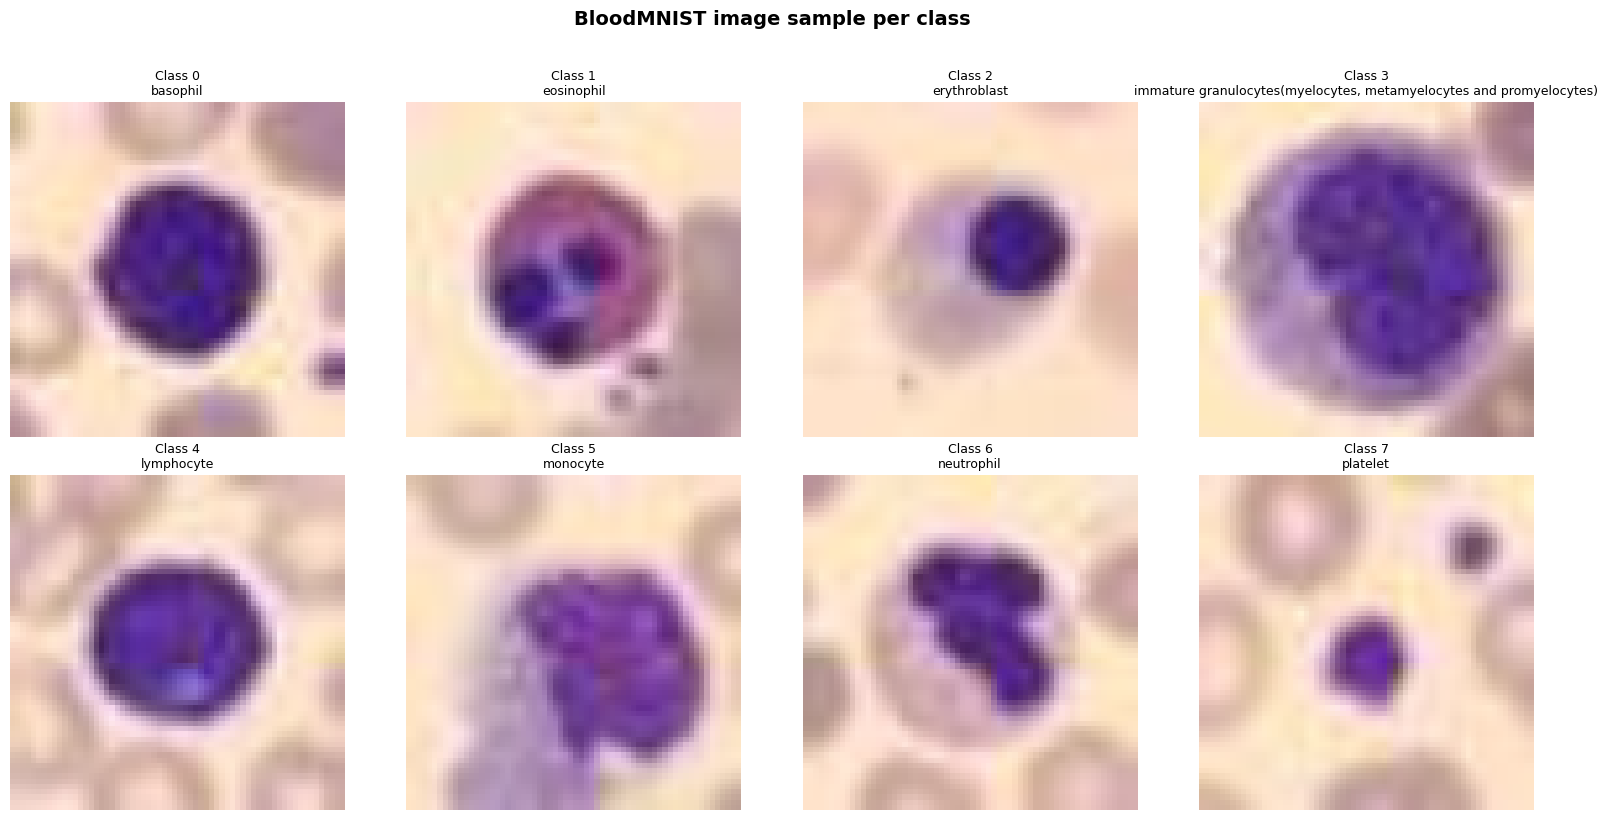

In [5]:
# Loading and exploration of the bloodMNIST dataset
transform = transforms.Compose(
    [
        transforms.Resize(BASE_CONFIG["img_size"]),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * BASE_CONFIG["channels"], [0.5] * BASE_CONFIG["channels"]),
    ]
)

dataset = medmnist.BloodMNIST(split="train", transform=transform, download=True)
dataloader = DataLoader(
    dataset, batch_size=BASE_CONFIG["batch_size"], shuffle=True, num_workers=2, pin_memory=True
)

# Class distribution
all_labels = [int(dataset[i][1]) for i in range(len(dataset))]

class_counts = Counter(all_labels)
info = INFO["bloodmnist"]
label_names = list(info["label"].values())

print(f"Dataset Overview:")
print(f"Number of samples: {len(dataset)}")
print(f"Image shape: {dataset[0][0].shape}")
print(f"Number of classes found: {len(class_counts)}")

print("\nClass distribution:")
for cls_idx, count in sorted(class_counts.items()):
    print(f"  Class {cls_idx} ({label_names[cls_idx]}): {count} samples")

# Plot sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for cls_idx in range(len(class_counts)):
    
    # Find first image of this class by iterating the dataset directly
    found = False # Used as a flag to check if an image for the class was found
    for i in range(len(dataset)):
        img, label = dataset[i]
        if int(label) == cls_idx:
            ax = axes[cls_idx // 4][cls_idx % 4]
            
            # Denormalise from [-1,1] to [0,1] for display
            img_display = img * 0.5 + 0.5
            ax.imshow(img_display.permute(1, 2, 0).numpy())
            ax.set_title(f"Class {cls_idx}\n{label_names[cls_idx]}", fontsize=9)
            ax.axis("off")
            found = True
            break
    if not found:
        print(f"No image found for class {cls_idx}")

plt.suptitle("BloodMNIST image sample per class", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
''' DCGAN architecture definition '''

# Discriminator architecture definition
class DCGANDiscriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            self._block(features_d, features_d * 2, 4, 2, 1),
            self._block(features_d * 2, features_d * 4, 4, 2, 1),
            self._block(features_d * 4, features_d * 8, 4, 2, 1),
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, z):
        return self.disc(z).view(-1)


# Generator architecture definition
class DCGANGenerator(nn.Module):
    def __init__(self, noise_dim, channels_img, features_g):
        super().__init__()
        self.gen = nn.Sequential(
            self._block(noise_dim, features_g * 16, 4, 1, 0),
            self._block(features_g * 16, features_g * 8, 4, 2, 1),
            self._block(features_g * 8, features_g * 4, 4, 2, 1),
            self._block(features_g * 4, features_g * 2, 4, 2, 1),
            nn.ConvTranspose2d(
                features_g * 2, channels_img, kernel_size=4, stride=2, padding=1
            ),
            nn.Tanh(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, z):
        return self.gen(z)


# Custom weight initialization function
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

In [7]:
# Fréchet Inception Distance Calculation
# This function computes the FID score between real images from the dataloader and fake images generated by the generator model.
def calculate_fid(dataloader, generator, noise_dim,
                  device=device, max_samples=5000):
    
    fid_metric = FrechetInceptionDistance(
        feature=2048, normalize=False).to(device)

    generator.eval()

    # Real images
    real_samples = 0
    for real_imgs, _ in dataloader:
        if real_samples >= max_samples:
            break
        real_imgs  = real_imgs.to(device)
        batch_take = min(real_imgs.size(0), max_samples - real_samples)
        real_imgs  = real_imgs[:batch_take]
        real_uint8 = ((real_imgs * 0.5 + 0.5).clamp(0, 1) * 255).to(torch.uint8)
        fid_metric.update(real_uint8, real=True)
        real_samples += batch_take

    # Fake images
    fake_samples = 0
    while fake_samples < max_samples:
        batch_take = min(dataloader.batch_size, max_samples - fake_samples)
        noise      = torch.randn(batch_take, noise_dim, 1, 1, device=device)
        with torch.no_grad():
            fake_imgs = generator(noise)
        fake_uint8 = ((fake_imgs * 0.5 + 0.5).clamp(0, 1) * 255).to(torch.uint8)
        fid_metric.update(fake_uint8, real=False)
        fake_samples += batch_take

    fid_score = fid_metric.compute().item()
    generator.train()

    return fid_score

In [8]:
'''
This function trains a DCGAN using the provided configuration and dataloader. 
It returns the trained generator, best model state, training losses, FID scores, 
and best FID score achieved during training.
'''

def train_gan(config, dataloader, max_samples= 1000, verbose=True):

    noise_dim    = config["noise_dim"]
    g_lr         = config["g_lr"]
    d_lr         = config["d_lr"]
    beta1        = config["beta1"]
    epochs       = config["epochs"]
    channels     = config["channels"]
    features_g   = config["features_g"]
    features_d   = config["features_d"]

    gen = DCGANGenerator(
        noise_dim=noise_dim, channels_img=channels, features_g=features_g
    ).to(device)
    disc = DCGANDiscriminator(
        channels_img=channels, features_d=features_d
    ).to(device)
    gen.apply(initialize_weights)
    disc.apply(initialize_weights)

    opt_g     = optim.Adam(gen.parameters(),  lr=g_lr, betas=(beta1, 0.999))
    opt_d     = optim.Adam(disc.parameters(), lr=d_lr, betas=(beta1, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    gen_losses, disc_losses, fid_scores = [], [], []
    best_fid   = float("inf")
    best_state = None

    for epoch in range(epochs):
        total_gen_loss, total_disc_loss = [], []

        for real_imgs, _ in dataloader:
            real_imgs  = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # ── Discriminator training
            noise     = torch.randn(batch_size, noise_dim, 1, 1, device=device)
            fake_imgs = gen(noise).detach()

            opt_d.zero_grad()
            loss_real = criterion(disc(real_imgs),
                                  torch.ones(batch_size, device=device) * 0.9)
            loss_fake = criterion(disc(fake_imgs),
                                  torch.zeros(batch_size, device=device))
            disc_loss = (loss_real + loss_fake) / 2
            disc_loss.backward()
            opt_d.step()

            # Generator training
            noise     = torch.randn(batch_size, noise_dim, 1, 1, device=device)
            fake_imgs = gen(noise)
            opt_g.zero_grad()
            gen_loss  = criterion(disc(fake_imgs),
                                      torch.ones(batch_size, device=device))
            gen_loss.backward()
            opt_g.step()

            total_gen_loss.append(gen_loss.item())
            total_disc_loss.append(disc_loss.item())

        gen_losses.append(np.mean(total_gen_loss))
        disc_losses.append(np.mean(total_disc_loss))

        # FID every 10 epochs
        if (epoch + 1) % 10 == 0 or (epoch + 1) == epochs:
            fid = calculate_fid(dataloader,
                                gen,
                                noise_dim=noise_dim,
                                max_samples = max_samples,
                                device=device)
            fid_scores.append(fid)

            if fid < best_fid:
                best_fid   = fid
                best_state = {i: j.detach().clone()
                              for i, j in gen.state_dict().items()}

            if verbose:
                print(f"Epoch [{epoch+1:3d}/{epochs}] | "
                      f"D Loss: {disc_losses[-1]:.4f} | "
                      f"G Loss: {gen_losses[-1]:.4f} | "
                      f"FID: {fid:.2f}")

    return {
        "generator"  : gen,
        "best_state" : best_state,
        "gen_losses" : gen_losses,
        "disc_losses": disc_losses,
        "fid_scores" : fid_scores,
        "best_fid"   : best_fid,
        "config"     : config
    }

In [21]:
# Generates and visualises real vs generated images from the dataloader and generator model.
def generate_images(
    dataloader,
    generator,
    num_images=64,
    noise_dim=100,
    device=device
):
    generator.eval()

    with torch.no_grad():
        noise = torch.randn(num_images, noise_dim, 1, 1, device=device)
        fake_images = generator(noise)

    generator.train()

    real_batch, _ = next(iter(dataloader))
    real_sample = real_batch[:num_images].to(device)

    real_sample = (real_sample * 0.5 + 0.5).clamp(0, 1)
    fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)

    real_grid = vutils.make_grid(real_sample, nrow=8, normalize=False, padding=2)
    fake_grid = vutils.make_grid(fake_images, nrow=8, normalize=False, padding=2)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(real_grid.cpu().permute(1, 2, 0))
    axes[0].axis("off")
    axes[0].set_title("Real BloodMNIST Images", fontsize=12)

    axes[1].imshow(fake_grid.cpu().permute(1, 2, 0))
    axes[1].axis("off")
    axes[1].set_title("Generated BloodMNIST Images", fontsize=12)

    plt.suptitle(
        f"BloodMNIST Real vs Generated",
        fontsize=14,
        fontweight="bold",
        y=1.02
    )
    plt.tight_layout()
    plt.show()

In [10]:
'''
This function samples a specified number of configurations from the hyperparameter search space,
combines them with the base configuration, and returns a list of configurations 
to be used for training multiple GANs with different hyperparameters.
'''

def sample_config(base_config, search_space, n_trials):
    search_keys = list(search_space.keys())
    search_values = [search_space[key] for key in search_keys]

    all_combinations = list(itertools.product(*search_values))

    combo = random.sample(all_combinations, k=min(n_trials, len(all_combinations)))

    configs = []
    for params_tuple in combo:
        config = base_config.copy()
        for i, key in enumerate(search_keys):
            config[key] = params_tuple[i]
        configs.append(config)

    return configs

In [11]:
'''
This function performs a random search over the specified hyperparameter search space,
training a GAN for each sampled configuration and evaluating its performance using FID.
It returns the best configuration found and a list of results for all configurations.
'''

def random_search(base_config, dataloader, search_space, n_trials=3):
    results = []
    configs = sample_config(base_config, search_space, n_trials)

    for i, params in enumerate(configs, start=1):
        print("\n")
        print(f"Random Search {i}")
        print("Config:", params)

        output = train_gan(params, dataloader, max_samples=500, verbose=False)

        results.append({
            "config": output["config"],
            "best_fid": output["best_fid"],
            "best_state": output["best_state"]
        })

        print(f"Random Search {i} Best FID: {output['best_fid']:.2f}")

    best_run = min(results, key=lambda x: x["best_fid"])
    return best_run, results

In [12]:
# Run the random search to find the best hyperparameters and train the GAN
best_run, all_results = random_search(BASE_CONFIG, dataloader, SEARCH_SPACE, n_trials=3)

# Display the best configuration and its FID score
print("\nBest Config Found:")
print(best_run["config"])
print("\n")
print(f"Best Tuning FID: {best_run['best_fid']:.2f}")



Random Search 1
Config: {'img_size': 64, 'channels': 3, 'noise_dim': 100, 'batch_size': 128, 'epochs': 5, 'g_lr': 0.0002, 'd_lr': 0.0001, 'beta1': 0.5, 'features_g': 128, 'features_d': 64}
Random Search 1 Best FID: 392.18


Random Search 2
Config: {'img_size': 64, 'channels': 3, 'noise_dim': 64, 'batch_size': 128, 'epochs': 5, 'g_lr': 0.0002, 'd_lr': 0.0001, 'beta1': 0.5, 'features_g': 64, 'features_d': 64}
Random Search 2 Best FID: 426.96


Random Search 3
Config: {'img_size': 64, 'channels': 3, 'noise_dim': 100, 'batch_size': 128, 'epochs': 5, 'g_lr': 0.0003, 'd_lr': 0.0001, 'beta1': 0.5, 'features_g': 128, 'features_d': 64}
Random Search 3 Best FID: 413.47

Best Config Found:
{'img_size': 64, 'channels': 3, 'noise_dim': 100, 'batch_size': 128, 'epochs': 5, 'g_lr': 0.0002, 'd_lr': 0.0001, 'beta1': 0.5, 'features_g': 128, 'features_d': 64}


Best Tuning FID: 392.18


In [13]:
# Train the GAN with the best configuration for more epochs to improve performance
final_config = best_run["config"].copy()
final_config["epochs"] = 10

final_result = train_gan(final_config, dataloader, max_samples=2000, verbose=True)

Epoch [ 10/10] | D Loss: 0.7015 | G Loss: 1.1678 | FID: 381.31


In [14]:
# Extract and Load the best model from the FINAL training run
final_generator = final_result["generator"]
final_generator.load_state_dict(final_result["best_state"])

<All keys matched successfully>

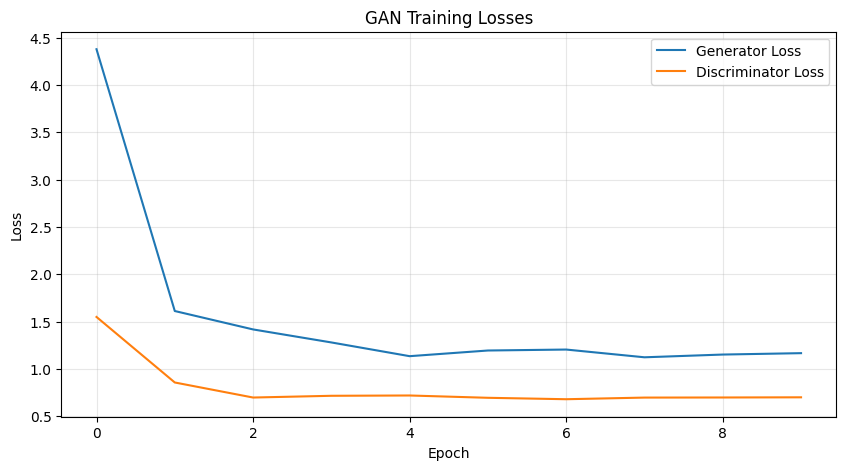

In [15]:
# plot the training losses for the final training run
plt.figure(figsize=(10, 5))
plt.plot(final_result["gen_losses"], label="Generator Loss")
plt.plot(final_result["disc_losses"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

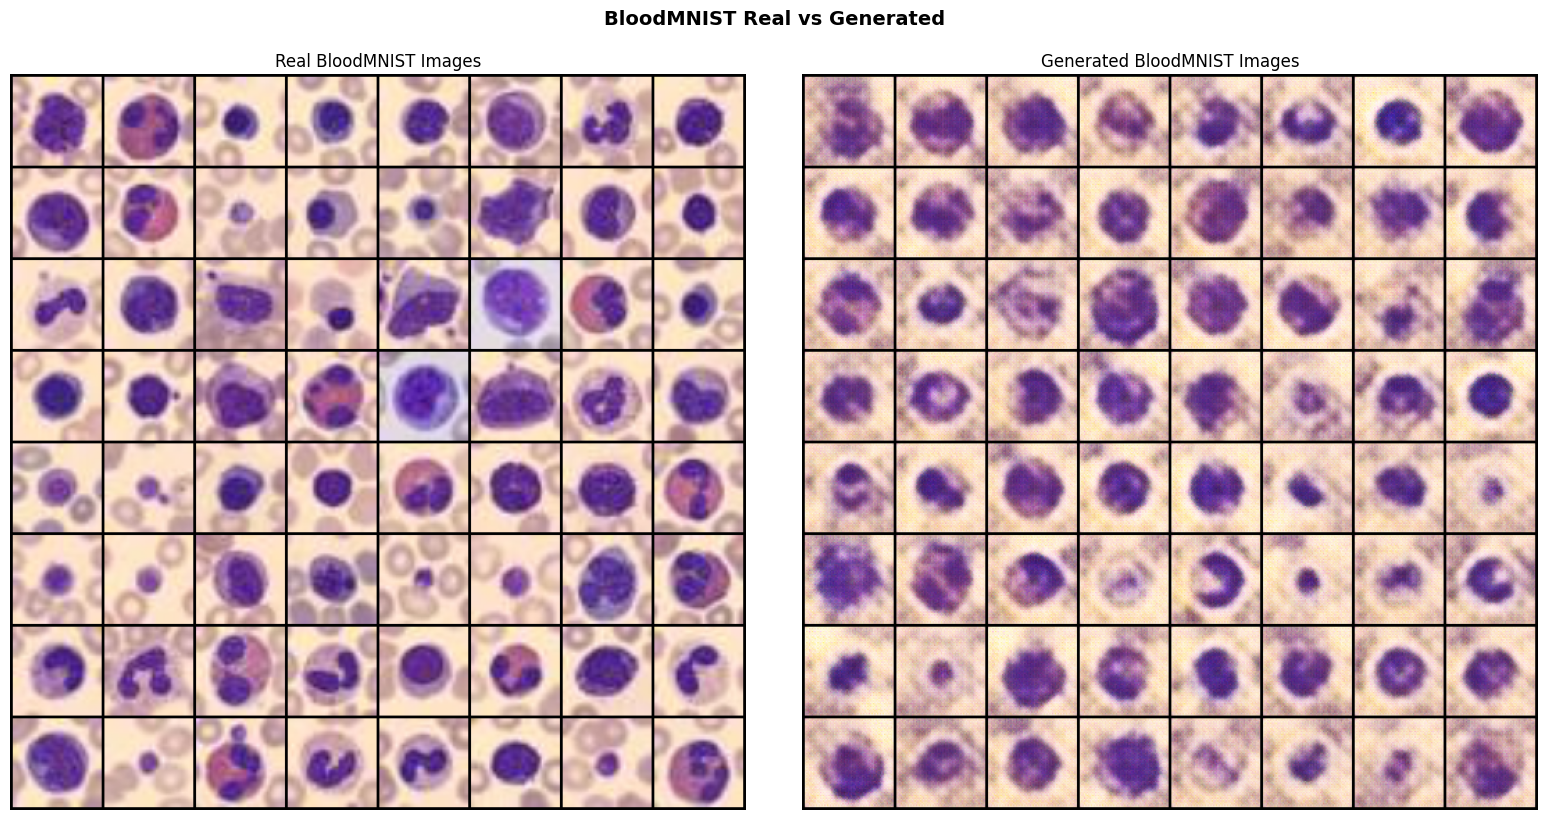

In [22]:
# Generate images using the final model which is the best model found
generate_images(
    dataloader=dataloader,
    generator=final_generator,
    num_images=64,
    noise_dim=final_config["noise_dim"],
    device=device
)

In [18]:
# Print the best FID score of the final model
print(f"Final Best FID: {final_result['best_fid']:.2f}")

Final Best FID: 381.31


In [19]:
# Recalculate the FID score of the final model
fid = calculate_fid(
    dataloader=dataloader,
    generator=final_generator,
    noise_dim=final_config["noise_dim"],
    max_samples=5000,
    device=device
)

print(f"Final FID of Final Model Config: {fid:.2f}")

Final FID of Final Model Config: 377.76
